# Data Loading

In [ ]:
import os
import numpy as np
import pandas as pd

from dataset_loader import load_tsa_data

# Load data
data = load_tsa_data()

X = data["data"]      # shape: (N, 60, 50)
y = data["target"]    # 1 = stable, 0 = unstable

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))

stable_mask = (y == 1)
unstable_mask = (y == 0)

X_stable = X[stable_mask]
X_unstable = X[unstable_mask]

print("Stable count:", X_stable.shape[0])
print("Unstable count:", X_unstable.shape[0])

X shape: (12852, 60, 50)
y shape: (12852,)
Unique labels: [0 1]
Stable count: 7460
Unstable count: 5392


In [ ]:
print(X_stable)

[[[724.866 370.973 479.109 ...  13.425  20.543 -37.06 ]
  [729.956 370.202 483.62  ...  13.565  20.711 -37.017]
  [734.748 371.432 487.478 ...  13.702  20.883 -36.966]
  ...
  [629.02  422.856 525.577 ...  15.405  20.635 -31.932]
  [627.916 423.039 526.023 ...  15.43   20.544 -31.98 ]
  [626.98  423.201 526.508 ...  15.454  20.458 -32.035]]

 [[668.145 361.883 475.286 ...  14.336  21.599 -36.859]
  [674.273 362.11  480.983 ...  14.517  21.839 -36.796]
  [679.905 364.217 485.971 ...  14.688  22.08  -36.724]
  ...
  [567.037 429.276 528.953 ...  15.714  19.641 -31.081]
  [567.032 429.37  529.606 ...  15.756  19.509 -31.169]
  [567.26  429.436 530.312 ...  15.796  19.387 -31.266]]

 [[637.193 358.569 475.687 ...  14.975  22.401 -36.688]
  [643.326 359.206 481.879 ...  15.171  22.677 -36.61 ]
  [648.896 361.681 487.326 ...  15.353  22.951 -36.523]
  ...
  [532.283 432.95  531.461 ...  15.897  18.953 -30.683]
  [533.043 432.987 532.275 ...  15.946  18.805 -30.801]
  [534.071 432.992 533.146

# Data Processing

## Train-test Split

In [ ]:
import numpy as np

np.random.seed(42)

stable_idx = np.where(y == 1)[0]
unstable_idx = np.where(y == 0)[0]

print("Total stable:", len(stable_idx))
print("Total unstable:", len(unstable_idx))

train_size = 5000
train_stable_idx = np.random.choice(stable_idx, size=train_size, replace=False)
eval_stable_idx = np.setdiff1d(stable_idx, train_stable_idx)
eval_unstable_idx = unstable_idx
X_train_stable = X[train_stable_idx]
X_eval_stable = X[eval_stable_idx]
X_eval_unstable = X[eval_unstable_idx]

print("Train stable:", X_train_stable.shape)
print("Eval stable:", X_eval_stable.shape)
print("Eval unstable:", X_eval_unstable.shape)
print("Train stable unique:", np.unique(y[train_stable_idx]))
print("Eval stable unique:", np.unique(y[eval_stable_idx]))
print("Eval unstable unique:", np.unique(y[eval_unstable_idx]))

Total stable: 7460
Total unstable: 5392
Train stable: (5000, 60, 50)
Eval stable: (2460, 60, 50)
Eval unstable: (5392, 60, 50)
Train stable unique: [1]
Eval stable unique: [1]
Eval unstable unique: [0]


## Normalization

In [ ]:
# ------------------------------------------
# 2) Compute normalization stats on train only
# ------------------------------------------
# Shape will be (1, 1, 50): one mean/std per feature
feat_mean = X_train_stable.mean(axis=(0, 1), keepdims=True)
feat_std = X_train_stable.std(axis=(0, 1), keepdims=True)

# avoid divide-by-zero
feat_std = np.where(feat_std < 1e-6, 1.0, feat_std)

print("\nNormalization stats:")
print("feat_mean shape:", feat_mean.shape)
print("feat_std shape:", feat_std.shape)
print("Any zero std:", np.any(feat_std == 0))

# ---------------------------
# 3) Apply normalization
# ---------------------------
X_train_stable = (X_train_stable - feat_mean) / feat_std
X_eval_stable = (X_eval_stable - feat_mean) / feat_std
X_eval_unstable = (X_eval_unstable - feat_mean) / feat_std

print("\nAfter normalization:")
print("Train stable mean (approx):", X_train_stable.mean(axis=(0, 1))[:5])
print("Train stable std  (approx):", X_train_stable.std(axis=(0, 1))[:5])

print("Eval stable shape:", X_eval_stable.shape)
print("Eval unstable shape:", X_eval_unstable.shape)


Normalization stats:
feat_mean shape: (1, 1, 50)
feat_std shape: (1, 1, 50)
Any zero std: False

After normalization:
Train stable mean (approx): [ 6.52540170e-15 -2.33865459e-14  2.46999401e-13 -6.82361586e-15
  9.61993337e-14]
Train stable std  (approx): [1. 1. 1. 1. 1.]
Eval stable shape: (2460, 60, 50)
Eval unstable shape: (5392, 60, 50)


## Prefix Split

In [ ]:
# import numpy as np

# def build_prefix_pairs(X_seq, k=5):
#     """
#     Convert trajectories into:
#       x      : flattened prefix, shape (N, k*D)
#       o_hist : prefix history, shape (N, k, D)
#       o_next : future trajectory, shape (N, T-k, D)

#     Args:
#         X_seq: np.ndarray, shape (N, T, D)
#         k: int, prefix length

#     Returns:
#         x, o_hist, o_next
#     """
#     assert X_seq.ndim == 3, f"Expected 3D array, got shape {X_seq.shape}"
#     N, T, D = X_seq.shape
#     assert k < T, f"k must be smaller than T, got k={k}, T={T}"

#     o_hist = X_seq[:, :k, :]          # (N, k, D)
#     o_next = X_seq[:, k:, :]          # (N, T-k, D)
#     x = o_hist.reshape(N, k * D)      # (N, k*D)

#     return x.astype(np.float32), o_hist.astype(np.float32), o_next.astype(np.float32)

# # prefix length
# k = 10

# # build train/eval pairs
# x_train, o_hist_train, o_next_train = build_prefix_pairs(X_train_stable, k=k)
# x_eval_stable, o_hist_eval_stable, o_next_eval_stable = build_prefix_pairs(X_eval_stable, k=k)
# x_eval_unstable, o_hist_eval_unstable, o_next_eval_unstable = build_prefix_pairs(X_eval_unstable, k=k)

# # sanity check
# print("Train:")
# print("x_train shape:", x_train.shape)
# print("o_hist_train shape:", o_hist_train.shape)
# print("o_next_train shape:", o_next_train.shape)

# print("\nEval stable:")
# print("x_eval_stable shape:", x_eval_stable.shape)
# print("o_hist_eval_stable shape:", o_hist_eval_stable.shape)
# print("o_next_eval_stable shape:", o_next_eval_stable.shape)

# print("\nEval unstable:")
# print("x_eval_unstable shape:", x_eval_unstable.shape)
# print("o_hist_eval_unstable shape:", o_hist_eval_unstable.shape)
# print("o_next_eval_unstable shape:", o_next_eval_unstable.shape)

import numpy as np

def build_sliding_pairs(X_seq, k=10):
    """
    Convert trajectories into sliding same-length pairs for old training code.

    Input:
        X_seq: shape (N, T, D)

    Output:
        x      : shape (M, k*D)      pseudo-context (prefix, repeated for each pair)
        o_hist : shape (M, k, D)
        o_next : shape (M, k, D)
    """
    assert X_seq.ndim == 3, f"Expected 3D array, got {X_seq.shape}"
    N, T, D = X_seq.shape
    assert 2 * k <= T, f"Need 2*k <= T, got k={k}, T={T}"

    x_list = []
    hist_list = []
    next_list = []

    for i in range(N):
        seq = X_seq[i]                # (T, D)
        context = seq[:k].reshape(-1)        # (k*D,)
        suffix = seq[k:]               # (T-k, D)
        L = suffix.shape[0]

        for start in range(L - 2 * k + 1):
            o_hist = suffix[start:start + k, :]
            o_next = suffix[start + k:start + 2 * k, :]

            x_list.append(context)
            hist_list.append(o_hist)
            next_list.append(o_next)

    x = np.asarray(x_list, dtype=np.float32)
    o_hist = np.asarray(hist_list, dtype=np.float32)
    o_next = np.asarray(next_list, dtype=np.float32)

    return x, o_hist, o_next


# use k=10
k = 10

x_train, o_hist_train, o_next_train = build_sliding_pairs(X_train_stable, k=k)
x_eval_stable, o_hist_eval_stable, o_next_eval_stable = build_sliding_pairs(X_eval_stable, k=k)
x_eval_unstable, o_hist_eval_unstable, o_next_eval_unstable = build_sliding_pairs(X_eval_unstable, k=k)

print("Train:")
print("x_train shape:", x_train.shape)
print("o_hist_train shape:", o_hist_train.shape)
print("o_next_train shape:", o_next_train.shape)

print("\nEval stable:")
print("x_eval_stable shape:", x_eval_stable.shape)
print("o_hist_eval_stable shape:", o_hist_eval_stable.shape)
print("o_next_eval_stable shape:", o_next_eval_stable.shape)

print("\nEval unstable:")
print("x_eval_unstable shape:", x_eval_unstable.shape)
print("o_hist_eval_unstable shape:", o_hist_eval_unstable.shape)
print("o_next_eval_unstable shape:", o_next_eval_unstable.shape)

Train:
x_train shape: (155000, 500)
o_hist_train shape: (155000, 10, 50)
o_next_train shape: (155000, 10, 50)

Eval stable:
x_eval_stable shape: (76260, 500)
o_hist_eval_stable shape: (76260, 10, 50)
o_next_eval_stable shape: (76260, 10, 50)

Eval unstable:
x_eval_unstable shape: (167152, 500)
o_hist_eval_unstable shape: (167152, 10, 50)
o_next_eval_unstable shape: (167152, 10, 50)


## Construct Data Loader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TSAPairDataset(Dataset):
    def __init__(self, x, o_hist, o_next):
        assert len(x) == len(o_hist) == len(o_next)
        self.x = torch.tensor(x, dtype=torch.float32)
        self.o_hist = torch.tensor(o_hist, dtype=torch.float32)
        self.o_next = torch.tensor(o_next, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.o_hist[idx], self.o_next[idx]


# -----------------------------
# Build datasets
# -----------------------------
train_dataset = TSAPairDataset(x_train, o_hist_train, o_next_train)
eval_stable_dataset = TSAPairDataset(x_eval_stable, o_hist_eval_stable, o_next_eval_stable)
eval_unstable_dataset = TSAPairDataset(x_eval_unstable, o_hist_eval_unstable, o_next_eval_unstable)

print("Train dataset size:", len(train_dataset))
print("Eval stable dataset size:", len(eval_stable_dataset))
print("Eval unstable dataset size:", len(eval_unstable_dataset))


# -----------------------------
# Build dataloaders
# -----------------------------
batch_train = 64
batch_eval = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_train,
    shuffle=True,
    drop_last=True
)

eval_stable_loader = DataLoader(
    eval_stable_dataset,
    batch_size=batch_eval,
    shuffle=False,
    drop_last=False
)

eval_unstable_loader = DataLoader(
    eval_unstable_dataset,
    batch_size=batch_eval,
    shuffle=False,
    drop_last=False
)

print("Train batches:", len(train_loader))
print("Eval stable batches:", len(eval_stable_loader))
print("Eval unstable batches:", len(eval_unstable_loader))


# -----------------------------
# Sanity check one batch
# -----------------------------
x_batch, o_hist_batch, o_next_batch = next(iter(train_loader))

print("\nOne train batch shapes:")
print("x_batch shape:", x_batch.shape)
print("o_hist_batch shape:", o_hist_batch.shape)
print("o_next_batch shape:", o_next_batch.shape)

Train dataset size: 155000
Eval stable dataset size: 76260
Eval unstable dataset size: 167152
Train batches: 2421
Eval stable batches: 596
Eval unstable batches: 1306

One train batch shapes:
x_batch shape: torch.Size([64, 500])
o_hist_batch shape: torch.Size([64, 10, 50])
o_next_batch shape: torch.Size([64, 10, 50])


# Training Encoder

In [ ]:
from pathlib import Path
import os, sys, random, time

import numpy as np
import torch

rng = np.random.default_rng(42)

def print_random_latents(name, v, n=20):
    v = v.reshape(-1)
    idx = rng.choice(len(v), size=min(n, len(v)), replace=False)
    print(f"\n{name} random {len(idx)} latents:")
    print(np.round(v[idx], 6))

# -------------------------
# Repo paths
# -------------------------
CWD = Path.cwd().resolve()
if (CWD / "src").exists():
    ROOT = CWD
else:
    ROOT = CWD.parents[0]

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# -------------------------
# Local modules (exact names from modeling_demo)
# -------------------------
from train.models import build_cond_gru_model, EncoderOnly
from train.training import (
    train_epoch,
    train_epoch_mmd_only,
    eval_epoch,
    eval_epoch_enc,
)
from train.losses import mmd2_unif

# -------------------------
# Config (same style as modeling_demo, only dims changed)
# -------------------------
class Cfg:
    seed = 1
    batch_train = 64
    batch_val = 128
    epochs = 15
    lr = 5e-3
    weight_decay = 1e-5
    lambda_mmd = 1e-1

    # changed for TSA
    d_x = 10 * 50         # k=10, each step has 50 features
    d_o = 50              # multivariate observation dimension
    d_v = 1
    d_h = 64
    hidden_enc = 128
    hidden_dec = 128
    B_bins = 10

In [ ]:
# -------------------------
# Reproducibility
# -------------------------
torch.manual_seed(Cfg.seed)
np.random.seed(Cfg.seed)
random.seed(Cfg.seed)

# -------------------------
# Device
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

# -------------------------
# Build model (exact function name from modeling_demo)
# -------------------------
model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
).to(device)

# Encoder-only variant (same as modeling_demo)
model_enc = EncoderOnly(model.enc).to(device)

# -------------------------
# Optimizers
# -------------------------
opt = torch.optim.Adam(
    model.parameters(),
    lr=Cfg.lr,
    weight_decay=Cfg.weight_decay
)

opt_enc = torch.optim.Adam(
    model_enc.parameters(),
    lr=Cfg.lr,
    weight_decay=Cfg.weight_decay
)

print(model)
print(model_enc)

# -------------------------
# Trial run: full model training
# exact style follows tuning runner:
#   train_epoch(model, train_loader, opt, lambda_mmd, device)
#   eval_epoch(val_loader, model, device)
# -------------------------
history = []

t0 = time.time()
for epoch in range(1, Cfg.epochs + 1):
    tr_loss = train_epoch(model, train_loader, opt, Cfg.lambda_mmd, device)
    va_rec, va_mmd = eval_epoch(eval_stable_loader, model, device)

    history.append({
        "epoch": epoch,
        "tr_loss": float(tr_loss),
        "va_rec": float(va_rec),
        "va_mmd": float(va_mmd),
    })

    print(
        f"[{epoch:02d}] "
        f"tr_loss={tr_loss:.4f}  "
        f"va_rec={va_rec:.4f}  "
        f"va_mmd={va_mmd:.4f}"
    )

print(f"Trial run finished in {(time.time() - t0):.2f} sec")

# -------------------------
# Optional: encoder-only MMD trial
# This matches the notebook imports/calls too.
# Keep it commented unless you want to try it.
# -------------------------
"""
history_enc = []

t0 = time.time()
for epoch in range(1, Cfg.epochs + 1):
    tr_loss_enc = train_epoch_mmd_only(model_enc, train_loader, opt_enc, Cfg.lambda_mmd, device)
    va_mmd_enc = eval_epoch_enc(eval_stable_loader, model_enc, device)

    history_enc.append({
        "epoch": epoch,
        "tr_loss_enc": float(tr_loss_enc),
        "va_mmd_enc": float(va_mmd_enc),
    })

    print(
        f"[ENC {epoch:02d}] "
        f"tr_loss={tr_loss_enc:.4f}  "
        f"va_mmd={va_mmd_enc:.4f}"
    )

print(f"Encoder-only trial finished in {(time.time() - t0):.2f} sec")
"""

# -------------------------
# Sanity check: encode one batch to latent
# exact access pattern from notebook: model.enc(xb)
# -------------------------
@torch.no_grad()
def encode_to_latent(model_any, X_array, device, batch_size=1024):
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    vs = []
    for start in range(0, X_tensor.shape[0], batch_size):
        xb = X_tensor[start:start + batch_size]
        if hasattr(model_any, "enc"):
            vb = model_any.enc(xb)
        else:
            vb = model_any(xb)
        vs.append(vb.detach().cpu())
    return torch.cat(vs, dim=0).numpy()

# take a small sample from eval stable just to verify latent shape
x_eval_stable_np = x_eval_stable.astype(np.float32)
v_eval_stable = encode_to_latent(model, x_eval_stable_np[:256], device=device)

print("Latent shape:", v_eval_stable.shape)
print_random_latents("TRAIN", v_eval_stable)

# Evaluation

In [ ]:
# import numpy as np
# import torch

# @torch.no_grad()
# def encode_array(model_any, X_array, device, batch_size=1024):
#     X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
#     vs = []
#     for start in range(0, X_tensor.shape[0], batch_size):
#         xb = X_tensor[start:start + batch_size]
#         if hasattr(model_any, "enc"):
#             vb = model_any.enc(xb)
#         else:
#             vb = model_any(xb)
#         vs.append(vb.detach().cpu().numpy())
#     return np.concatenate(vs, axis=0)   # shape: (N, 1)

# def summarize_latents(name, v, bins=10):
#     v = np.asarray(v).reshape(-1)

#     print(f"\n===== {name} =====")
#     print("shape:", v.shape)
#     print("min  :", float(np.min(v)))
#     print("max  :", float(np.max(v)))
#     print("mean :", float(np.mean(v)))
#     print("std  :", float(np.std(v)))

#     qs = [0.0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
#     qv = np.quantile(v, qs)
#     print("quantiles:")
#     for q, val in zip(qs, qv):
#         print(f"  q={q:>4}: {val:.6f}")

#     uniq_6 = np.unique(np.round(v, 6)).shape[0]
#     uniq_4 = np.unique(np.round(v, 4)).shape[0]
#     print("unique count (rounded 6dp):", uniq_6)
#     print("unique count (rounded 4dp):", uniq_4)

#     print("random 20 values:")
#     print_random_latents(v)

#     counts, edges = np.histogram(v, bins=bins)
#     print(f"histogram counts ({bins} bins):", counts.tolist())
#     print("bin edges:", [round(x, 6) for x in edges.tolist()])


# # -------------------------
# # 1) encode all latent values
# # -------------------------
# v_train = encode_array(model, x_train, device=device, batch_size=1024)
# v_eval_stable = encode_array(model, x_eval_stable, device=device, batch_size=1024)
# v_eval_unstable = encode_array(model, x_eval_unstable, device=device, batch_size=1024)

# # -------------------------
# # 2) summarize
# # -------------------------
# summarize_latents("TRAIN", v_train, bins=10)
# summarize_latents("EVAL_STABLE", v_eval_stable, bins=10)
# summarize_latents("EVAL_UNSTABLE", v_eval_unstable, bins=10)

In [ ]:
import numpy as np
from hypo_test.stats_tests import chisq_uniform_1d

import numpy as np
from hypo_test.stats_tests import chisq_uniform_1d

def rejection_rate_from_latents(
    v,
    batch_size=128,
    n_repeats=200,
    alpha=0.05,
    bins=10,
    seed=42,
    replace=True,
):
    rng = np.random.default_rng(seed)
    v = np.asarray(v).reshape(-1)

    rejects = []
    pvals = []
    stats_list = []

    for _ in range(n_repeats):
        idx = rng.choice(len(v), size=batch_size, replace=replace)
        v_batch = v[idx]

        chi2, pval, counts = chisq_uniform_1d(v_batch, bins)

        stats_list.append(chi2)
        pvals.append(pval)
        rejects.append(pval < alpha)

    return {
        "rejection_rate": float(np.mean(rejects)),
        "mean_pvalue": float(np.mean(pvals)),
        "median_pvalue": float(np.median(pvals)),
        "mean_chi2": float(np.mean(stats_list)),
        "pvals": np.array(pvals),
        "rejects": np.array(rejects, dtype=bool),
    }

In [ ]:
import numpy as np
import torch

# -------------------------
# 1) build one unique context per trajectory
# -------------------------
def build_unique_context(X_seq, k=10):
    """
    X_seq: np.ndarray, shape (N, T, D)
    return:
        x_unique: np.ndarray, shape (N, k*D)
    """
    assert X_seq.ndim == 3, f"Expected 3D array, got {X_seq.shape}"
    N, T, D = X_seq.shape
    assert k < T, f"k must be smaller than T, got k={k}, T={T}"

    x_unique = X_seq[:, :k, :].reshape(N, k * D).astype(np.float32)
    return x_unique


# -------------------------
# 2) encode array to latent
# exact style compatible with your current model usage
# -------------------------
@torch.no_grad()
def encode_array(model_any, X_array, device, batch_size=1024):
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    vs = []

    for start in range(0, X_tensor.shape[0], batch_size):
        xb = X_tensor[start:start + batch_size]

        if hasattr(model_any, "enc"):
            vb = model_any.enc(xb)
        else:
            vb = model_any(xb)

        vs.append(vb.detach().cpu().numpy())

    return np.concatenate(vs, axis=0)   # shape: (N, 1)


# -------------------------
# 3) build unique contexts from trajectory-level data
# use the ORIGINAL normalized trajectory splits:
#   X_train_stable
#   X_eval_stable
#   X_eval_unstable
# -------------------------
k = 10

x_train_unique = build_unique_context(X_train_stable, k=k)
x_eval_stable_unique = build_unique_context(X_eval_stable, k=k)
x_eval_unstable_unique = build_unique_context(X_eval_unstable, k=k)

print("Unique context shapes:")
print("x_train_unique:", x_train_unique.shape)
print("x_eval_stable_unique:", x_eval_stable_unique.shape)
print("x_eval_unstable_unique:", x_eval_unstable_unique.shape)


# -------------------------
# 4) encode to latent
# -------------------------
v_train_unique = encode_array(model, x_train_unique, device=device, batch_size=1024)
v_eval_stable_unique = encode_array(model, x_eval_stable_unique, device=device, batch_size=1024)
v_eval_unstable_unique = encode_array(model, x_eval_unstable_unique, device=device, batch_size=1024)

print("\nUnique latent shapes:")
print("v_train_unique:", v_train_unique.shape)
print("v_eval_stable_unique:", v_eval_stable_unique.shape)
print("v_eval_unstable_unique:", v_eval_unstable_unique.shape)


# -------------------------
# 5) quick sanity check
# -------------------------
print("\nFirst 10 unique stable latents:")
print(np.round(v_eval_stable_unique[:10].reshape(-1), 6))

print("\nFirst 10 unique unstable latents:")
print(np.round(v_eval_unstable_unique[:10].reshape(-1), 6))

In [ ]:
alpha = 0.0001
bins = 10
batch_size_test = 128
n_repeats = 200

stable_res = rejection_rate_from_latents(
    v_eval_stable_unique,
    batch_size=batch_size_test,
    n_repeats=n_repeats,
    alpha=alpha,
    bins=bins,
    seed=42,
    replace=True,
)

unstable_res = rejection_rate_from_latents(
    v_eval_unstable_unique,
    batch_size=batch_size_test,
    n_repeats=n_repeats,
    alpha=alpha,
    bins=bins,
    seed=43,
    replace=True,
)

print("Stable rejection rate:", stable_res["rejection_rate"])
print("Stable mean p-value   :", stable_res["mean_pvalue"])
print("Stable median p-value :", stable_res["median_pvalue"])
print("Stable mean chi2      :", stable_res["mean_chi2"])

print()

print("Unstable rejection rate:", unstable_res["rejection_rate"])
print("Unstable mean p-value   :", unstable_res["mean_pvalue"])
print("Unstable median p-value :", unstable_res["median_pvalue"])
print("Unstable mean chi2      :", unstable_res["mean_chi2"])

Stable rejection rate: 0.01
Stable mean p-value   : 0.22324972742852942
Stable median p-value : 0.10561781257979624
Stable mean chi2      : 14.63359375

Unstable rejection rate: 1.0
Unstable mean p-value   : 1.2313012748843554e-08
Unstable median p-value : 4.1466829969749597e-13
Unstable mean chi2      : 77.63828125


## Loop over lambda

In [ ]:
lambda_grid = [1e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1, 5, 10]
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)
p0_rates = []
p1_rates = []

for lam in lambda_grid:

    print("\n==============================")
    print("lambda_mmd =", lam)
    print("==============================")

    # rebuild model
    model = build_cond_gru_model(
        d_x=Cfg.d_x,
        d_o=Cfg.d_o,
        d_v=Cfg.d_v,
        d_h=Cfg.d_h,
        hidden_enc=Cfg.hidden_enc,
        hidden_dec=Cfg.hidden_dec,
        output_activation="sigmoid",
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=Cfg.lr,
        weight_decay=Cfg.weight_decay
    )

    # train
    for epoch in range(Cfg.epochs):
        train_epoch(model, train_loader, optimizer, lam, device)

    # encode latent
    v_eval_stable = encode_array(model, x_eval_stable_unique, device)
    v_eval_unstable = encode_array(model, x_eval_unstable_unique, device)

    # rejection test
    stable_res = rejection_rate_from_latents(v_eval_stable,alpha=0.0001)
    unstable_res = rejection_rate_from_latents(v_eval_unstable,alpha=0.0001)

    p0 = stable_res["rejection_rate"]
    p1 = unstable_res["rejection_rate"]

    print("P0 rejection:", p0)
    print("P1 rejection:", p1)

    p0_rates.append(p0)
    p1_rates.append(p1)

device: cuda

lambda_mmd = 0.001
P0 rejection: 0.035
P1 rejection: 0.78

lambda_mmd = 0.01
P0 rejection: 0.01
P1 rejection: 1.0

lambda_mmd = 0.05
P0 rejection: 0.0
P1 rejection: 1.0

lambda_mmd = 0.1
P0 rejection: 0.075
P1 rejection: 1.0

lambda_mmd = 0.5
P0 rejection: 0.0
P1 rejection: 1.0

lambda_mmd = 1
P0 rejection: 0.005
P1 rejection: 1.0

lambda_mmd = 5
P0 rejection: 0.015
P1 rejection: 1.0

lambda_mmd = 10
P0 rejection: 0.04
P1 rejection: 1.0


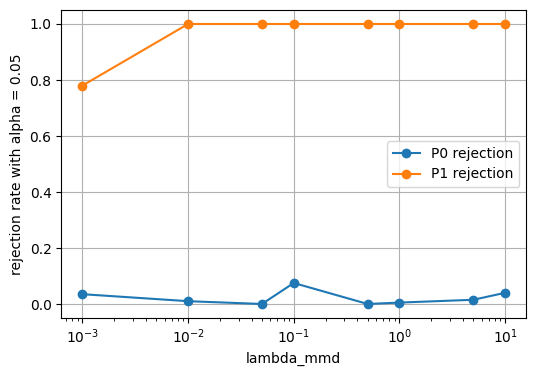

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(lambda_grid, p0_rates, marker='o', label='P0 rejection')
plt.plot(lambda_grid, p1_rates, marker='o', label='P1 rejection')
plt.xscale("log")
plt.xlabel("lambda_mmd")
plt.ylabel("rejection rate with alpha = 0.05")
plt.legend()
plt.grid(True)
plt.show()